# brightness data learning curve

Extracted from the former `build_curate_split_brightness.ipynb`; the data-build/curate/split upstream now lives in `../dataset_pipeline/`. This notebook reads the curated brightness dataset from `../dataset_pipeline/data/brightness/curated/` and evaluates how test error scales with training-set size (fixed 85/15 split, seed 0).

In [ ]:
import os, sys
# Moved into scalar_design/ (sibling of peak_design/). peak_models.py lives in
# peak_design/, so add it to the import path; the relative data/model paths below
# (../dataset_pipeline, trained_models_brightness/) resolve unchanged because this
# folder sits at the same depth as peak_design/.
sys.path.insert(0, os.path.abspath("../peak_design"))

In [ ]:
# --- Setup: curated brightness data + per-residue ESM-2 embeddings + fixed 85/15 test ---
# Repointed to the dataset_pipeline curated set. The ESM-2 residue cache is built once from the
# curated sequences (in row order) and saved alongside the data; delete it to force a rebuild.
import os, csv, json
import numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self, k):
        return getattr(apc, k) if HAVE_APC else {"aegean": "#2b6c8f", "amber": "#f6a200",
            "rose": "#c5474b", "seaweed": "#3b8a6e", "gray": "#9a9a9a"}.get(k, "#333")
C = _C()
dev = torch.device('mps') if (getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()) \
      else (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))

cur = '../dataset_pipeline/data/brightness/curated'
TDM_B = 'trained_models_brightness'; os.makedirs(TDM_B, exist_ok=True)

lc_rows = list(csv.DictReader(open(f'{cur}/brightness_assignments.csv'))); Nlc = len(lc_rows)
lc_seqs = [None] * Nlc; h = None
for line in open(f'{cur}/sequences.fasta'):
    line = line.strip()
    if line.startswith('>'): h = int(line[1:].split('|')[0])
    elif line: lc_seqs[h] = line
Braw = np.load(f'{cur}/brightness.npy').astype(np.float32).ravel()
y = np.log1p(Braw).astype(np.float32)                             # train/eval in log space

# per-residue ESM-2 embedding cache for this curated set (row-aligned; built once)
EMB = f'{cur}/esm_residue_fp16.npy'; LN = f'{cur}/esm_residue_len.npy'
Ls = np.array([len(s) for s in lc_seqs], dtype=np.int64); Lmax = int(Ls.max())
if os.path.exists(EMB) and os.path.exists(LN):
    H = np.load(EMB); Ls = np.load(LN); Lmax = H.shape[1]
    print(f'loaded ESM-2 residue cache: {EMB}')
else:
    H = np.zeros((Nlc, Lmax, pm.D_IN), dtype=np.float16)
    for i0 in range(0, Nlc, 16):
        chunk = lc_seqs[i0:i0 + 16]; Hm, _ = pm.resid_embed(chunk, dev)
        for k, s in enumerate(chunk):
            H[i0 + k, :len(s)] = Hm[k, :len(s)].cpu().numpy().astype(np.float16)
    np.save(EMB, H); np.save(LN, Ls)
    print(f'built ESM-2 residue cache for {Nlc} seqs -> {EMB}')
Ht = torch.tensor(H); ar = torch.arange(Lmax); Yt = torch.tensor(y, device=dev).unsqueeze(1)

# fixed held-out 15% test (seed 0); the remaining 85% is the training pool
perm = np.random.default_rng(0).permutation(Nlc); n_te = int(round(0.15 * Nlc))
TEST = perm[:n_te]; POOL = perm[n_te:]
print(f'device {dev} | curated N={Nlc} | fixed 15% test={len(TEST)} | 85% pool={len(POOL)}')

def batches(idx, bs=32, shuffle=False, rng=None):
    idx = np.array(idx)
    if shuffle: rng.shuffle(idx)
    for i in range(0, len(idx), bs):
        b = idx[i:i + bs]
        yield Ht[b].float().to(dev), (ar.unsqueeze(0) < torch.tensor(Ls[b]).unsqueeze(1)).to(dev), b

def mae_log(net, idx):
    net.eval(); ps = []
    with torch.no_grad():
        for Hb, mk_, b in batches(idx): ps.append(net(Hb, mk_).cpu().numpy())
    return float(np.abs(np.concatenate(ps).ravel() - y[idx]).mean())

def train_eval(pool, tr_idx, te_idx, seed, epochs=70, save_path=None):
    torch.manual_seed(seed); rng = np.random.default_rng(100 + seed)
    mean = np.array([y[tr_idx].mean()], np.float32); std = np.array([y[tr_idx].std() + 1e-6], np.float32)
    sd = torch.tensor(std, device=dev)
    spec = dict(arch='cnn', pool=pool, conv_ch=128, k=5, hidden=256, nl=2)
    net = pm.wrap(pm.build_base(spec, dev, out=1, drop=0.2), mean, std, dev)
    opt = torch.optim.Adam(net.parameters(), 1e-3, weight_decay=1e-4)
    for ep in range(epochs):
        net.train()
        for Hb, mk_, b in batches(tr_idx, shuffle=True, rng=rng):
            opt.zero_grad()
            (((net(Hb, mk_) - Yt[torch.as_tensor(b, device=dev)]) / sd) ** 2).mean().backward(); opt.step()
    if save_path is not None:
        pm.save_model(save_path, net.base, dict(spec, drop=0.2, out=1, mean=mean, std=std,
                                                n_train=len(tr_idx), seed=seed))
    return mae_log(net, te_idx), mae_log(net, tr_idx)


### 6.1 Sweep training-set size (cached; 3 subset draws per point)

In [10]:
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; POOLS=['max','concat']; EPOCHS=70
LC_CACHE=f'{TDM_B}/brightness_learning_curve_sweep.json'
LC_DIR=f'{TDM_B}/lc_models'; os.makedirs(LC_DIR, exist_ok=True)
def lc_path(pool, f, sd): return f'{LC_DIR}/cnn-{pool}_p{int(round(f*100))}_s{sd}.pt'
if os.path.exists(LC_CACHE):
    res = json.load(open(LC_CACHE)); print(f'loaded sweep cache: {LC_CACHE}')
    for pool in POOLS:
        r = res[pool]
        for i, f in enumerate(r['frac']):
            print(f"  cnn-{pool:6} {int(f*100):3d}% pool | n_train={r['n'][i]:4d} | test MAE {r['te_mean'][i]:.3f} +/- {r['te_std'][i]:.3f} log | train MAE {r['tr_mean'][i]:.3f}")
else:
    res = {p: {'n':[], 'frac':[], 'te_mean':[], 'te_std':[], 'tr_mean':[], 'tr_std':[]} for p in POOLS}
    for pool in POOLS:
        print(f'--- cnn-{pool} ---')
        for f in FRACS:
            n = int(round(f*len(POOL))); te, tr = [], []
            for sd in SEEDS:
                sub = np.random.default_rng(sd).choice(POOL, n, replace=False)
                t_te, t_tr = train_eval(pool, sub, TEST, sd, epochs=EPOCHS, save_path=lc_path(pool, f, sd))
                te.append(t_te); tr.append(t_tr)
            r = res[pool]; r['n'].append(n); r['frac'].append(f)
            r['te_mean'].append(float(np.mean(te))); r['te_std'].append(float(np.std(te)))
            r['tr_mean'].append(float(np.mean(tr))); r['tr_std'].append(float(np.std(tr)))
            print(f'  {int(f*100):3d}% pool | n_train={n:4d} | test MAE {np.mean(te):.3f} +/- {np.std(te):.3f} log | train MAE {np.mean(tr):.3f}')
    json.dump(res, open(LC_CACHE,'w'), indent=2)
    print(f'saved sweep cache: {LC_CACHE}  ({len(FRACS)*len(SEEDS)*len(POOLS)} checkpoints -> {LC_DIR}/)')

loaded sweep cache: trained_models_brightness/brightness_learning_curve_sweep.json
  cnn-max     10% pool | n_train=  45 | test MAE 0.842 +/- 0.083 log | train MAE 0.102
  cnn-max     20% pool | n_train=  91 | test MAE 0.742 +/- 0.017 log | train MAE 0.079
  cnn-max     50% pool | n_train= 227 | test MAE 0.683 +/- 0.076 log | train MAE 0.218
  cnn-max     80% pool | n_train= 363 | test MAE 0.554 +/- 0.044 log | train MAE 0.113
  cnn-max    100% pool | n_train= 454 | test MAE 0.511 +/- 0.042 log | train MAE 0.165
  cnn-concat  10% pool | n_train=  45 | test MAE 0.822 +/- 0.065 log | train MAE 0.120
  cnn-concat  20% pool | n_train=  91 | test MAE 0.760 +/- 0.032 log | train MAE 0.073
  cnn-concat  50% pool | n_train= 227 | test MAE 0.703 +/- 0.036 log | train MAE 0.197
  cnn-concat  80% pool | n_train= 363 | test MAE 0.524 +/- 0.063 log | train MAE 0.146
  cnn-concat 100% pool | n_train= 454 | test MAE 0.506 +/- 0.015 log | train MAE 0.170


### 6.2 Learning curve

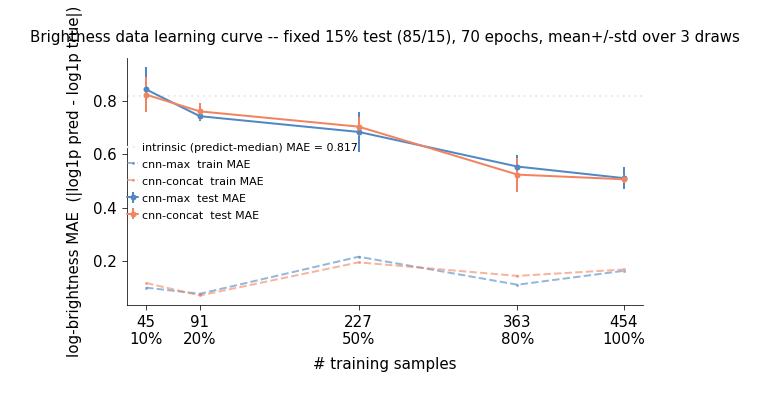

intrinsic (predict-median) log-brightness MAE = 0.817
cnn-max: test MAE 0.842 @ 45 (10%) -> 0.511 log @ 454 (100%); train-test gap at full = +0.346 log; removes 38% of the intrinsic-baseline error
cnn-concat: test MAE 0.822 @ 45 (10%) -> 0.506 log @ 454 (100%); train-test gap at full = +0.336 log; removes 38% of the intrinsic-baseline error


In [11]:
# intrinsic (no-information) baseline: the best a model with NO sequence input can do.
# For MAE the optimal constant is the median, so intrinsic MAE = MAE of predicting the pool's
# median log-brightness on the fixed test set. Model MAE below this line = what it actually learned.
intrinsic_mae = float(np.abs(y[TEST] - np.median(y[POOL])).mean())

fig, ax = plt.subplots(figsize=(8.5, 5.2))
col = {'max': C.aegean, 'concat': C.amber}
ax.axhline(intrinsic_mae, ls=':', lw=2.2, color=C.gray, zorder=0,
           label=f'intrinsic (predict-median) MAE = {intrinsic_mae:.3f}')
for pool in POOLS:
    r = res[pool]; n = np.array(r['n'])
    ax.errorbar(n, r['te_mean'], yerr=r['te_std'], marker='o', capsize=3, color=col[pool], label=f'cnn-{pool}  test MAE')
    ax.plot(n, r['tr_mean'], ls='--', marker='.', color=col[pool], alpha=0.6, label=f'cnn-{pool}  train MAE')
ax.set_xlabel('# training samples'); ax.set_ylabel('log-brightness MAE  (|log1p pred - log1p true|)')
ax.set_title('Brightness data learning curve -- fixed 15% test (85/15), 70 epochs, mean+/-std over 3 draws')
ax.legend(fontsize=11); ax.set_xticks(res['max']['n'])
ax.set_xticklabels([f'{n}\n{int(f*100)}%' for n, f in zip(res['max']['n'], res['max']['frac'])])
plt.tight_layout(); fig.savefig(f'{TDM_B}/brightness_learning_curve_85_15.png', dpi=130, bbox_inches='tight'); plt.show()
print(f'intrinsic (predict-median) log-brightness MAE = {intrinsic_mae:.3f}')
for pool in POOLS:
    r = res[pool]; frac = 100*(1 - r['te_mean'][-1]/intrinsic_mae)
    print(f"cnn-{pool}: test MAE {r['te_mean'][0]:.3f} @ {r['n'][0]} (10%) -> {r['te_mean'][-1]:.3f} log @ {r['n'][-1]} (100%); "
          f"train-test gap at full = {r['te_mean'][-1]-r['tr_mean'][-1]:+.3f} log; "
          f"removes {frac:.0f}% of the intrinsic-baseline error")

### 6.3 Train vs test parity -- where is evaluation trustworthy?

Reloads the full-pool `cnn-concat` (seed 0 -- the top point of the curve, cached in 6.1) and predicts brightness
for every curated FP. Parity plots split by 85/15 membership show the gap between the **train** fit (optimistic
-- the model saw these labels) and the **held-out test** fit (the honest estimate of generalization).

group   n    MAE(log)   R2(log)   Spearman(raw)
  train pool    454  0.208     0.92     0.97
  held-out test   80  0.527     0.43     0.68


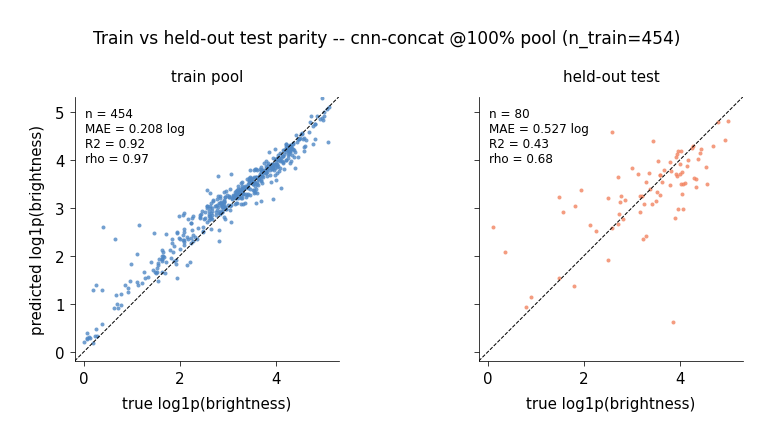

In [12]:
from scipy.stats import spearmanr
FULL_POOL='concat'; FULL_SEED=0; mpath = lc_path(FULL_POOL, 1.0, FULL_SEED)
if not os.path.exists(mpath):                       # 6.1 not run yet -> train just this one fit
    train_eval(FULL_POOL, POOL, TEST, FULL_SEED, epochs=EPOCHS, save_path=mpath)
base, ck = pm.load_model(mpath, dev, out=1); net = pm.wrap(base, ck['mean'], ck['std'], dev)
net.eval(); ps=[]
with torch.no_grad():
    for Hb, mk_, b in batches(np.arange(Nlc)): ps.append(net(Hb, mk_).cpu().numpy())
pred_log = np.concatenate(ps).ravel(); pred = np.expm1(pred_log)
is_test = np.zeros(Nlc, bool); is_test[TEST] = True
def _r2(t, p): return 1 - np.sum((p-t)**2)/np.sum((t-t.mean())**2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharex=True, sharey=True)
lim = [np.log1p(Braw).min()-0.2, np.log1p(Braw).max()+0.2]
print('group   n    MAE(log)   R2(log)   Spearman(raw)')
for ax, (name, m, cc) in zip(axes, [('train pool', ~is_test, C.aegean), ('held-out test', is_test, C.amber)]):
    idx = np.where(m)[0]; t = y[idx]; p = pred_log[idx]
    mae = np.abs(p-t).mean(); r2 = _r2(t, p); rho = spearmanr(Braw[idx], pred[idx])[0]
    print(f'  {name:12} {len(idx):4d}  {mae:.3f}    {r2:5.2f}    {rho:5.2f}')
    ax.plot(lim, lim, ls='--', color='k', lw=1)
    ax.scatter(t, p, s=16, alpha=0.8, color=cc)
    ax.text(0.04, 0.96, f'n = {len(idx)}\nMAE = {mae:.3f} log\nR2 = {r2:.2f}\nrho = {rho:.2f}', transform=ax.transAxes, va='top', fontsize=12)
    ax.set_xlabel('true log1p(brightness)'); ax.set_title(name); ax.set_box_aspect(1); ax.set_xlim(lim); ax.set_ylim(lim)
axes[0].set_ylabel('predicted log1p(brightness)')
plt.suptitle(f'Train vs held-out test parity -- cnn-{FULL_POOL} @100% pool (n_train={ck.get("n_train")})')
plt.tight_layout(); fig.savefig(f'{TDM_B}/brightness_parity_train_vs_test.png', dpi=130, bbox_inches='tight'); plt.show()

### 6.4 Reading the curve for the dual-split decision

Interpretation (see the printed numbers and the two figures above):
- **How much did it learn?** The dotted **intrinsic** line is the MAE of a no-information predictor (the pool's
  median log-brightness). The vertical gap from that line down to the test-MAE curve is what the sequence model
  actually buys; the printed `removes N% of the intrinsic-baseline error` quantifies it. If the curve sat on the
  line, the model would have learned nothing beyond the target's central value.
- **Is the data enough?** If the test-MAE curve is still descending at 100% pool, brightness prediction is
  **data-limited** -- every held-out sample is costly, which argues *against* spending 30% of the set on two
  separate 15% holdouts (surrogate test + oracle test). If it has plateaued, the split budget is affordable.
- **Where is evaluation trustworthy?** The train-vs-test parity gap is the honest-error tax: the **train** fit is
  optimistic (labels were seen), so only the **held-out test** R2/MAE should be trusted when reporting model
  quality. This is the core reason the dual scheme keeps a real, unseen test set for each model rather than
  trusting in-sample fit.
- **One model or two?** The dual surrogate/oracle design exists so each model's test set is *in-sample* for the
  other -- enabling the in-sample-vs-OOD design evaluation. If the learning curve shows a small train-test gap
  and a plateau, a **single** regressor with one clean 85/15 split is a defensible, data-efficient alternative;
  if the gap is large or the curve steep, the redundancy of two coordinated models (and the extra held-out
  data it protects) is worth the cost. The cached checkpoints let you reload any fit without retraining.